In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('C:/SupplyChainAssistant/src')
from pipeline import run_pipeline

# Run pipeline to get clean data
df = run_pipeline('C:/SupplyChainAssistant/data/supply_chain_data.csv')

print("Clean data ready for visualization!")
print("Shape:", df.shape)

SUPPLY CHAIN DATA CLEANING PIPELINE
LOADING DATA
SUCCESS: CSV file loaded.
Rows loaded: 100
Columns loaded: 24

--- Step 1: Standardizing Column Names ---
  Renamed: 'Product type' → 'product_type'
  Renamed: 'SKU' → 'sku'
  Renamed: 'Price' → 'price'
  Renamed: 'Availability' → 'availability'
  Renamed: 'Number of products sold' → 'number_of_products_sold'
  Renamed: 'Revenue generated' → 'revenue_generated'
  Renamed: 'Customer demographics' → 'customer_demographics'
  Renamed: 'Stock levels' → 'stock_levels'
  Renamed: 'Lead times' → 'supplier_lead_time'
  Renamed: 'Order quantities' → 'order_quantities'
  Renamed: 'Shipping times' → 'shipping_times'
  Renamed: 'Shipping carriers' → 'shipping_carriers'
  Renamed: 'Shipping costs' → 'shipping_costs'
  Renamed: 'Supplier name' → 'supplier_name'
  Renamed: 'Location' → 'location'
  Renamed: 'Lead time' → 'customer_lead_time'
  Renamed: 'Production volumes' → 'production_volumes'
  Renamed: 'Manufacturing lead time' → 'manufacturing_lea

In [2]:
# Make all charts look clean and professional
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
sns.set_palette("husl")

print("Chart styling ready!")

Chart styling ready!


Plotting distributions for 15 numeric columns...


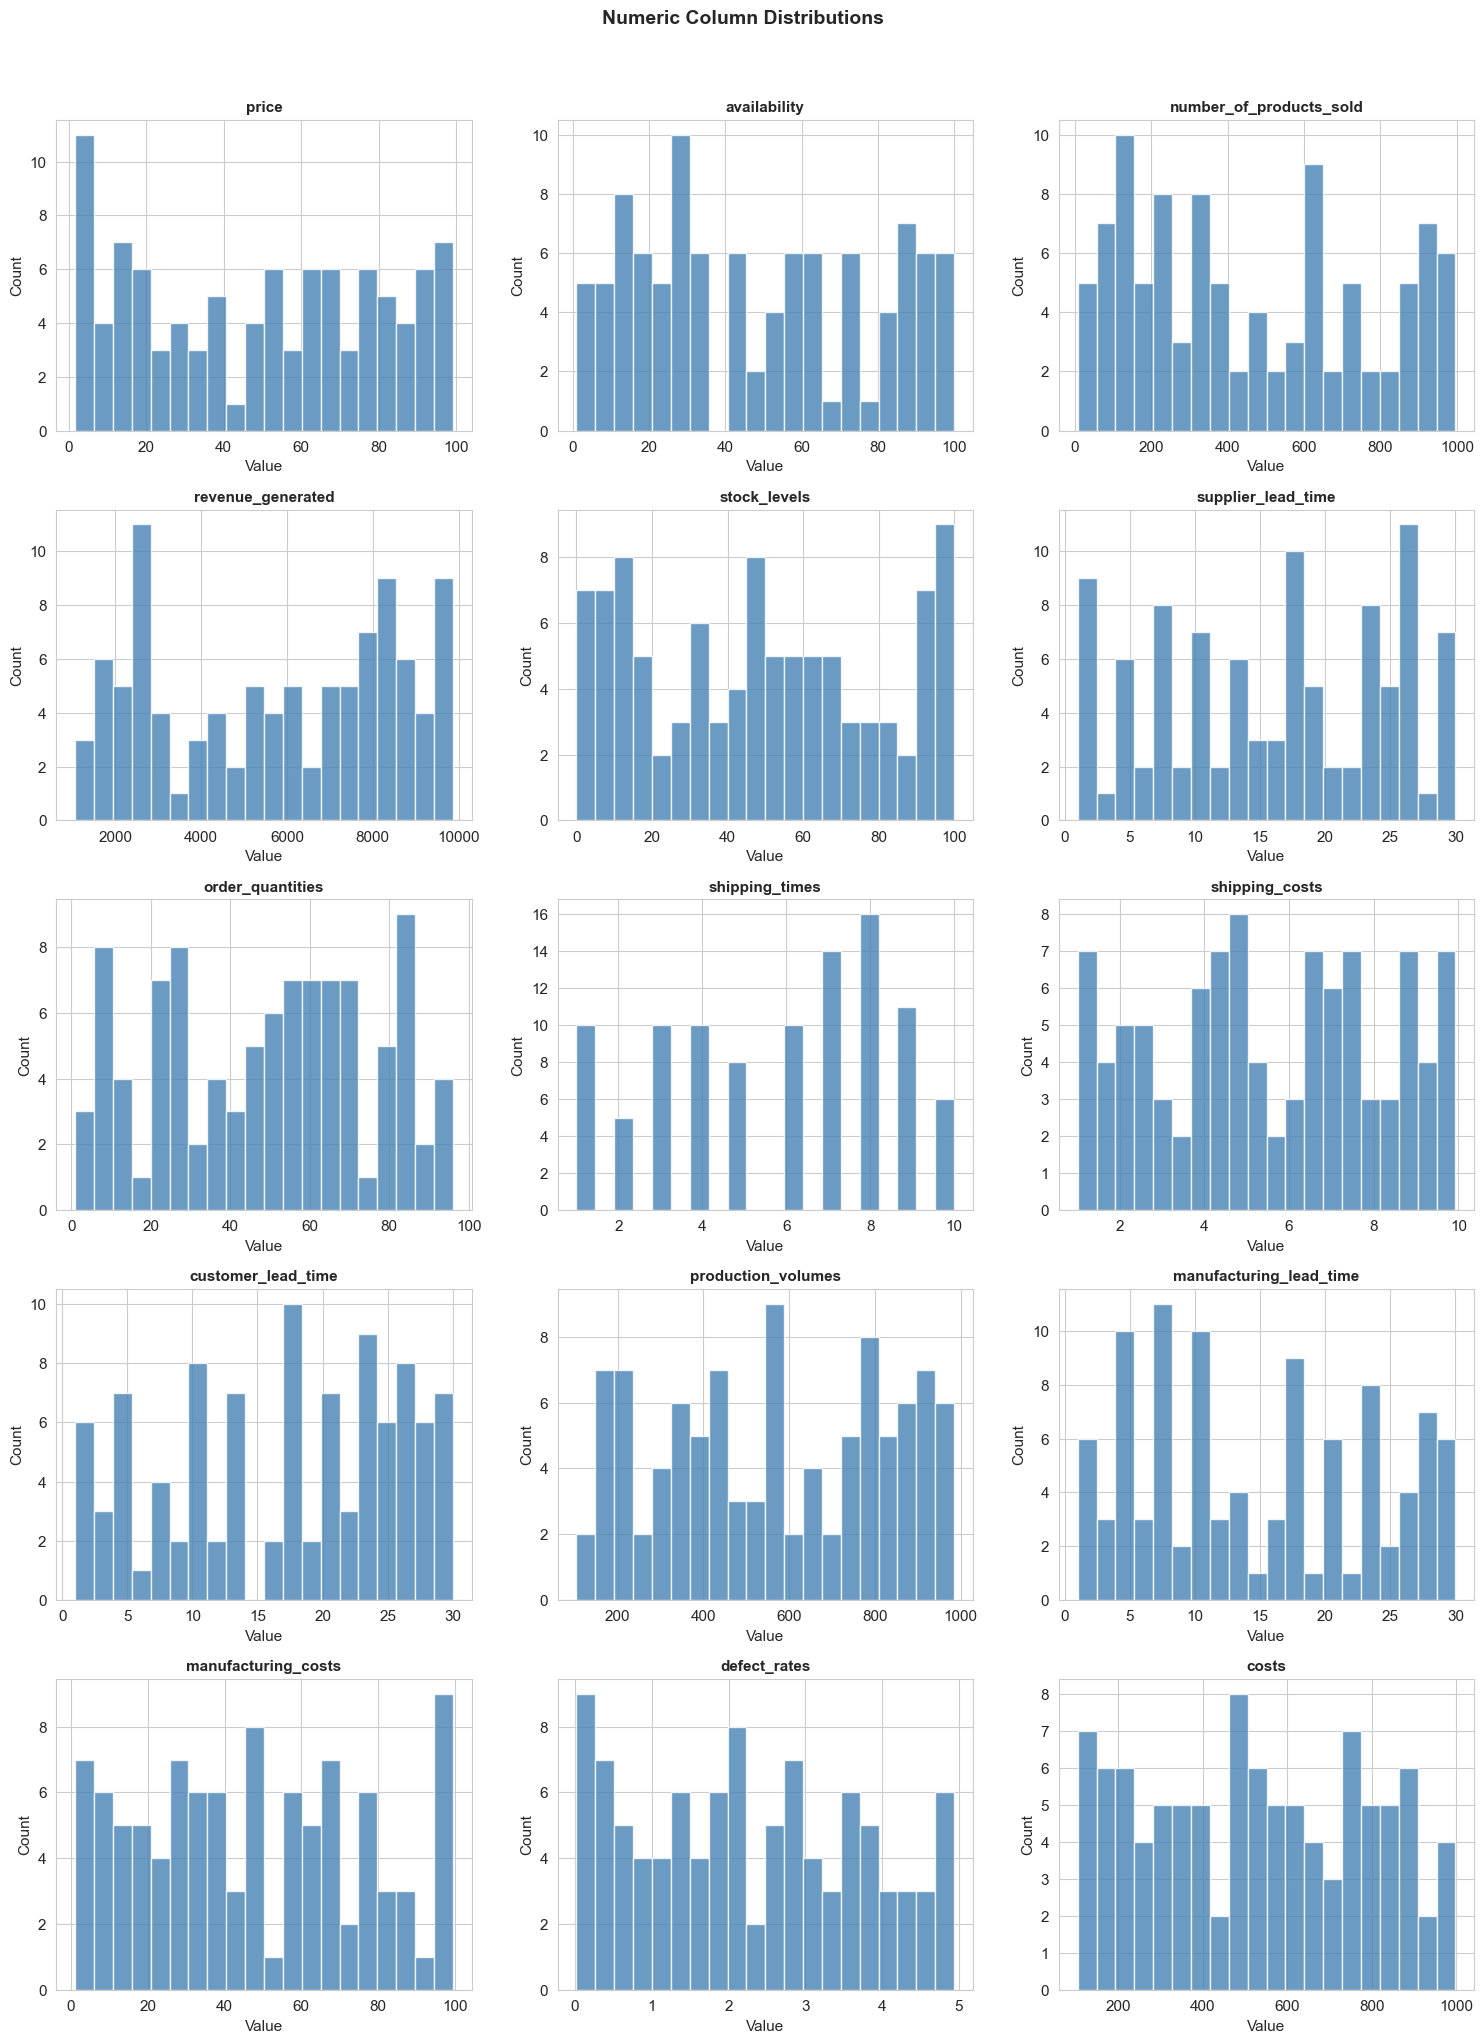

✓ Saved: numeric_distributions.png


In [3]:
def plot_numeric_distributions(df):
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    
    print(f"Plotting distributions for {len(numeric_cols)} numeric columns...")
    
    # Calculate grid size
    cols = 3
    rows = (len(numeric_cols) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col], bins=20, color='steelblue', 
                     edgecolor='white', alpha=0.8)
        axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Count')
    
    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Numeric Column Distributions', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('C:/SupplyChainAssistant/outputs/numeric_distributions.png',
                bbox_inches='tight')
    plt.show()
    print("✓ Saved: numeric_distributions.png")

plot_numeric_distributions(df)

Plotting bar charts for 8 categorical columns...


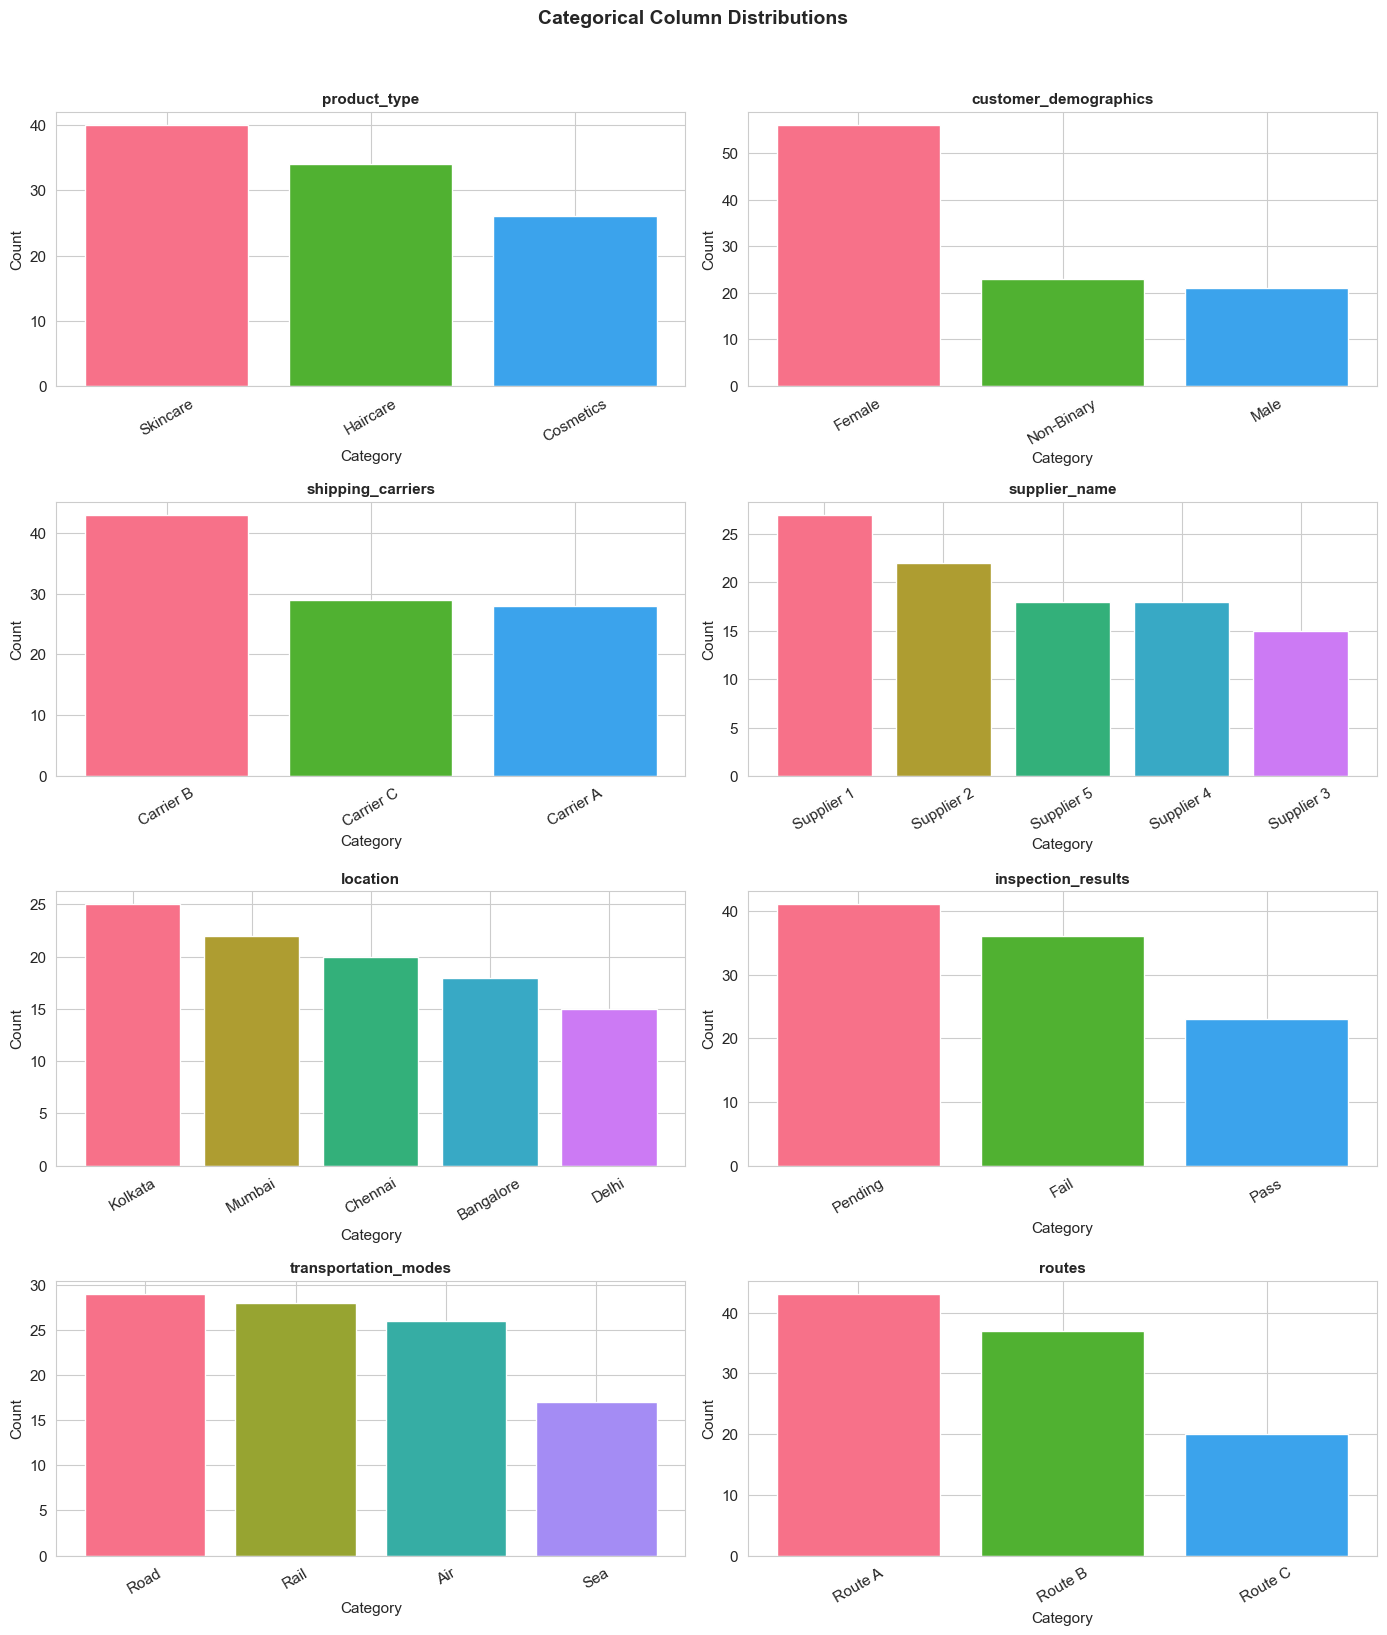

✓ Saved: categorical_distributions.png


In [4]:
def plot_categorical_distributions(df):
    # Skip ID-like columns
    cat_cols = [col for col in df.select_dtypes(include='object').columns
                if df[col].nunique() < 15]
    
    print(f"Plotting bar charts for {len(cat_cols)} categorical columns...")
    
    cols = 2
    rows = (len(cat_cols) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(cat_cols):
        value_counts = df[col].value_counts()
        axes[i].bar(value_counts.index, value_counts.values,
                   color=sns.color_palette("husl", len(value_counts)))
        axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Category')
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=30)
    
    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Categorical Column Distributions',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('C:/SupplyChainAssistant/outputs/categorical_distributions.png',
                bbox_inches='tight')
    plt.show()
    print("✓ Saved: categorical_distributions.png")

plot_categorical_distributions(df)

Plotting correlation heatmap...


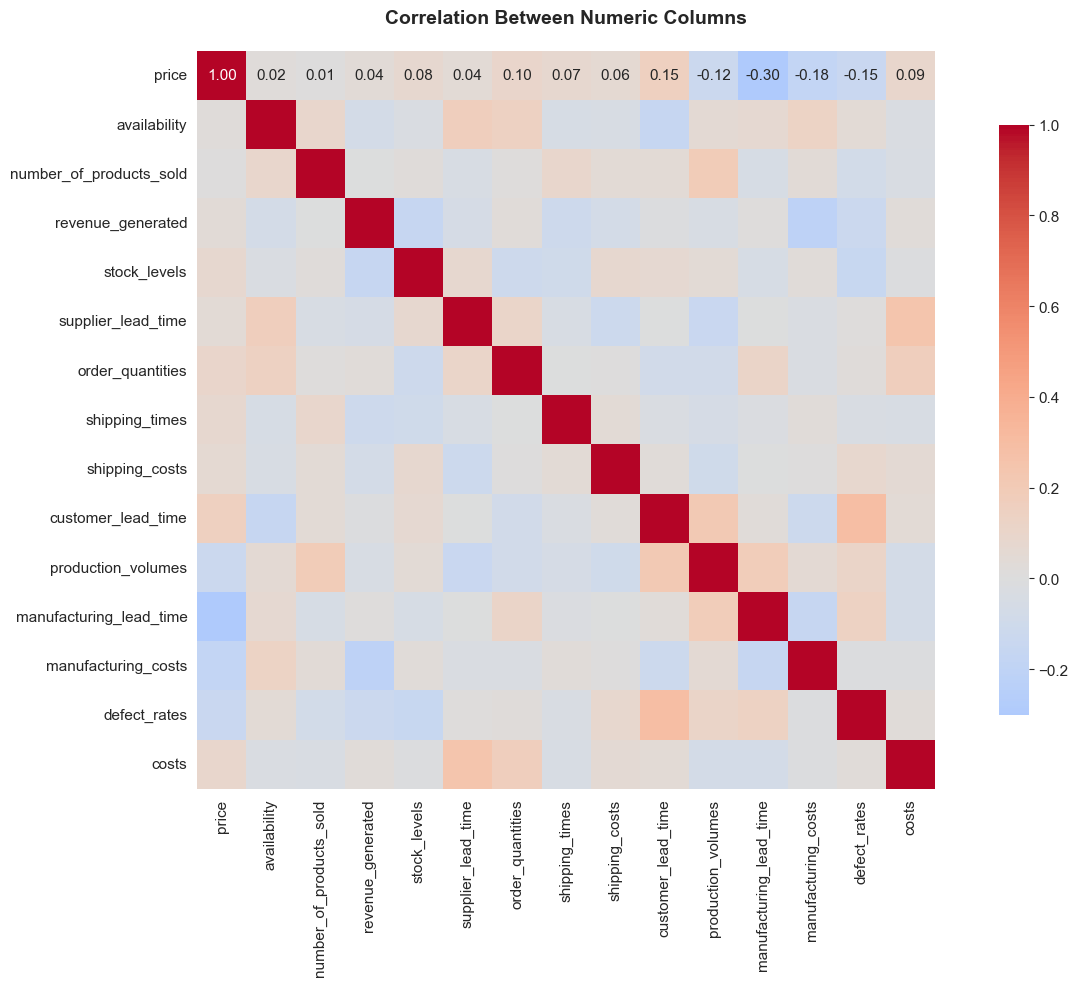

✓ Saved: correlation_heatmap.png


In [5]:
def plot_correlation_heatmap(df):
    print("Plotting correlation heatmap...")
    
    numeric_df = df.select_dtypes(include='number')
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    correlation = numeric_df.corr()
    
    sns.heatmap(correlation, 
                annot=True, 
                fmt='.2f',
                cmap='coolwarm',
                center=0,
                square=True,
                ax=ax,
                cbar_kws={'shrink': 0.8})
    
    ax.set_title('Correlation Between Numeric Columns',
                fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('C:/SupplyChainAssistant/outputs/correlation_heatmap.png',
                bbox_inches='tight')
    plt.show()
    print("✓ Saved: correlation_heatmap.png")

plot_correlation_heatmap(df)

SUPPLIER PERFORMANCE ANALYSIS

📊 Average Defect Rate by Supplier:
  Supplier 5: 2.67% ⚠️  HIGH
  Supplier 3: 2.47% ⚠️  HIGH
  Supplier 2: 2.36% ⚠️  HIGH
  Supplier 4: 2.34% ⚠️  HIGH
  Supplier 1: 1.80%

📊 Average Lead Time by Supplier (days):
  Supplier 4: 17.0 days ⚠️  SLOW
  Supplier 1: 16.8 days ⚠️  SLOW
  Supplier 2: 16.2 days ⚠️  SLOW
  Supplier 5: 14.7 days
  Supplier 3: 14.3 days


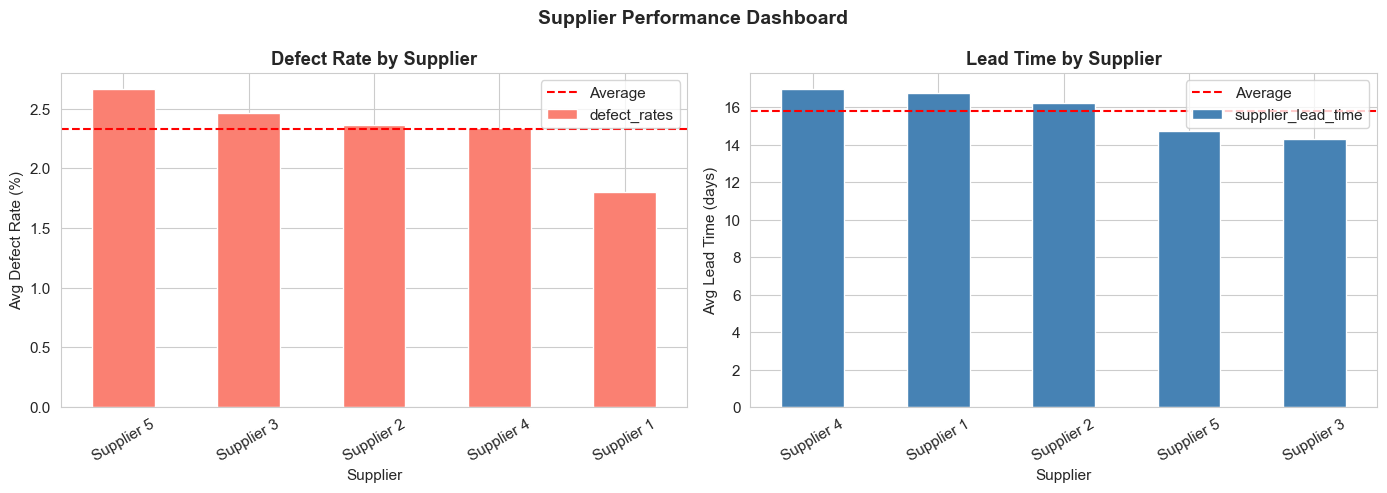


💡 KEY INSIGHTS:
  → Highest defect rate: Supplier 5 (2.67%)
  → Lowest defect rate: Supplier 1 (1.80%)
  → Slowest supplier: Supplier 4 (17.0 days avg lead time)


In [6]:
def analyze_supplier_performance(df):
    print("=" * 50)
    print("SUPPLIER PERFORMANCE ANALYSIS")
    print("=" * 50)
    
    insights = []
    
    # Average defect rate by supplier
    supplier_defects = df.groupby('supplier_name')['defect_rates'].mean().sort_values(ascending=False)
    
    print("\n📊 Average Defect Rate by Supplier:")
    for supplier, rate in supplier_defects.items():
        flag = " ⚠️  HIGH" if rate > supplier_defects.mean() else ""
        print(f"  {supplier}: {rate:.2f}%{flag}")
    
    worst_supplier = supplier_defects.index[0]
    best_supplier = supplier_defects.index[-1]
    insights.append(f"Highest defect rate: {worst_supplier} ({supplier_defects[worst_supplier]:.2f}%)")
    insights.append(f"Lowest defect rate: {best_supplier} ({supplier_defects[best_supplier]:.2f}%)")
    
    # Average lead time by supplier
    supplier_leadtime = df.groupby('supplier_name')['supplier_lead_time'].mean().sort_values(ascending=False)
    
    print("\n📊 Average Lead Time by Supplier (days):")
    for supplier, days in supplier_leadtime.items():
        flag = " ⚠️  SLOW" if days > supplier_leadtime.mean() else ""
        print(f"  {supplier}: {days:.1f} days{flag}")
    
    slowest_supplier = supplier_leadtime.index[0]
    insights.append(f"Slowest supplier: {slowest_supplier} ({supplier_leadtime[slowest_supplier]:.1f} days avg lead time)")
    
    # Plot supplier performance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    supplier_defects.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='white')
    axes[0].set_title('Defect Rate by Supplier', fontweight='bold')
    axes[0].set_xlabel('Supplier')
    axes[0].set_ylabel('Avg Defect Rate (%)')
    axes[0].axhline(y=supplier_defects.mean(), color='red', 
                    linestyle='--', label='Average')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=30)
    
    supplier_leadtime.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].set_title('Lead Time by Supplier', fontweight='bold')
    axes[1].set_xlabel('Supplier')
    axes[1].set_ylabel('Avg Lead Time (days)')
    axes[1].axhline(y=supplier_leadtime.mean(), color='red',
                    linestyle='--', label='Average')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=30)
    
    plt.suptitle('Supplier Performance Dashboard', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('C:/SupplyChainAssistant/outputs/supplier_performance.png',
                bbox_inches='tight')
    plt.show()
    
    print("\n💡 KEY INSIGHTS:")
    for insight in insights:
        print(f"  → {insight}")
    
    return insights

supplier_insights = analyze_supplier_performance(df)

QUALITY & INSPECTION ANALYSIS

📊 Inspection Results Overview:
  Pending: 41 products (41.0%)
  Fail: 36 products (36.0%) ⚠️  CRITICAL
  Pass: 23 products (23.0%)

📊 Defect Rate by Product Type:
  Haircare: 2.48% ⚠️
  Skincare: 2.33% ⚠️
  Cosmetics: 1.92%


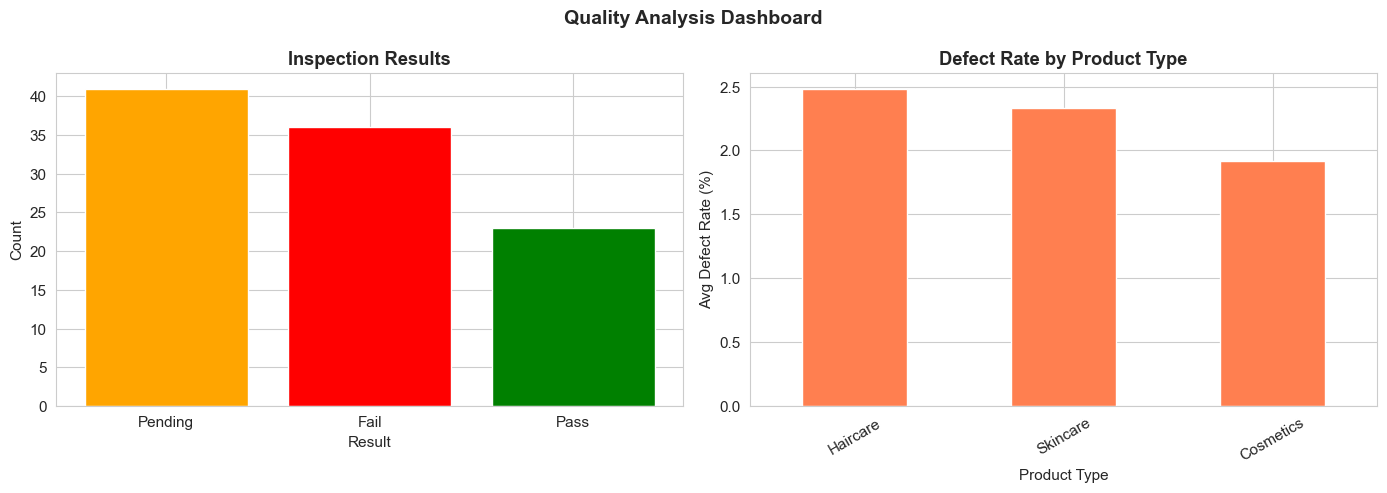


💡 KEY INSIGHTS:
  → CRITICAL: 36.0% of products are failing inspection
  → WARNING: Only 23.0% of products passing inspection
  → Highest defect product: Haircare (2.48%)


In [7]:
def analyze_quality(df):
    print("=" * 50)
    print("QUALITY & INSPECTION ANALYSIS")
    print("=" * 50)
    
    insights = []
    
    # Overall inspection results
    inspection_counts = df['inspection_results'].value_counts()
    total = len(df)
    
    print("\n📊 Inspection Results Overview:")
    for result, count in inspection_counts.items():
        pct = (count / total) * 100
        flag = " ⚠️  CRITICAL" if result == 'Fail' and pct > 20 else ""
        print(f"  {result}: {count} products ({pct:.1f}%){flag}")
    
    fail_pct = (inspection_counts.get('Fail', 0) / total) * 100
    pass_pct = (inspection_counts.get('Pass', 0) / total) * 100
    
    if fail_pct > 20:
        insights.append(f"CRITICAL: {fail_pct:.1f}% of products are failing inspection")
    if pass_pct < 30:
        insights.append(f"WARNING: Only {pass_pct:.1f}% of products passing inspection")
    
    # Defect rate by product type
    product_defects = df.groupby('product_type')['defect_rates'].mean().sort_values(ascending=False)
    
    print("\n📊 Defect Rate by Product Type:")
    for product, rate in product_defects.items():
        flag = " ⚠️" if rate > product_defects.mean() else ""
        print(f"  {product}: {rate:.2f}%{flag}")
    
    worst_product = product_defects.index[0]
    insights.append(f"Highest defect product: {worst_product} ({product_defects[worst_product]:.2f}%)")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = {'Pass': 'green', 'Fail': 'red', 'Pending': 'orange'}
    bar_colors = [colors.get(x, 'gray') for x in inspection_counts.index]
    
    axes[0].bar(inspection_counts.index, inspection_counts.values,
               color=bar_colors, edgecolor='white')
    axes[0].set_title('Inspection Results', fontweight='bold')
    axes[0].set_xlabel('Result')
    axes[0].set_ylabel('Count')
    
    product_defects.plot(kind='bar', ax=axes[1], 
                        color='coral', edgecolor='white')
    axes[1].set_title('Defect Rate by Product Type', fontweight='bold')
    axes[1].set_xlabel('Product Type')
    axes[1].set_ylabel('Avg Defect Rate (%)')
    axes[1].tick_params(axis='x', rotation=30)
    
    plt.suptitle('Quality Analysis Dashboard',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('C:/SupplyChainAssistant/outputs/quality_analysis.png',
                bbox_inches='tight')
    plt.show()
    
    print("\n💡 KEY INSIGHTS:")
    for insight in insights:
        print(f"  → {insight}")
    
    return insights

quality_insights = analyze_quality(df)

SHIPPING & ROUTE ANALYSIS

📊 Average Shipping Time by Carrier (days):
  Carrier A: 6.1 days ⚠️  SLOW
  Carrier C: 6.0 days ⚠️  SLOW
  Carrier B: 5.3 days

📊 Average Shipping Cost by Route:
  Route C: 5.90 ⚠️  EXPENSIVE
  Route B: 5.55
  Route A: 5.38


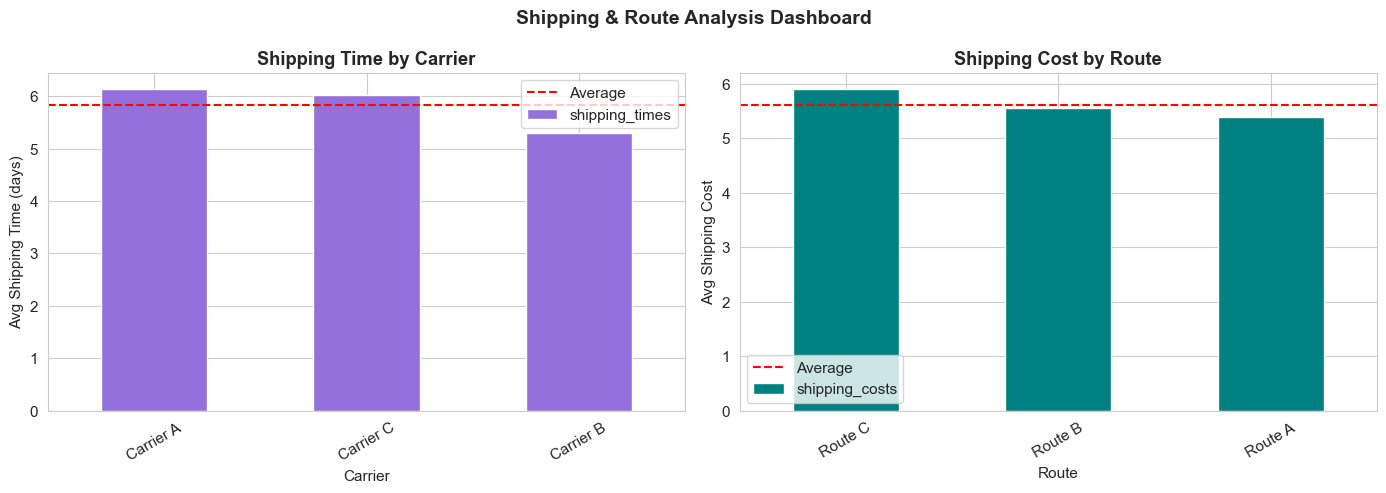


💡 KEY INSIGHTS:
  → Slowest carrier: Carrier A (6.1 days avg)
  → Most expensive route: Route C (avg cost 5.90)
  → Underutilised route: Route C (only 20 shipments)


In [8]:
def analyze_shipping(df):
    print("=" * 50)
    print("SHIPPING & ROUTE ANALYSIS")
    print("=" * 50)
    
    insights = []
    
    # Average shipping time by carrier
    carrier_times = df.groupby('shipping_carriers')['shipping_times'].mean().sort_values(ascending=False)
    
    print("\n📊 Average Shipping Time by Carrier (days):")
    for carrier, days in carrier_times.items():
        flag = " ⚠️  SLOW" if days > carrier_times.mean() else ""
        print(f"  {carrier}: {days:.1f} days{flag}")
    
    slowest_carrier = carrier_times.index[0]
    insights.append(f"Slowest carrier: {slowest_carrier} ({carrier_times[slowest_carrier]:.1f} days avg)")
    
    # Average shipping cost by route
    route_costs = df.groupby('routes')['shipping_costs'].mean().sort_values(ascending=False)
    
    print("\n📊 Average Shipping Cost by Route:")
    for route, cost in route_costs.items():
        flag = " ⚠️  EXPENSIVE" if cost > route_costs.mean() else ""
        print(f"  {route}: {cost:.2f}{flag}")
    
    expensive_route = route_costs.index[0]
    insights.append(f"Most expensive route: {expensive_route} (avg cost {route_costs[expensive_route]:.2f})")
    
    # Route utilisation
    route_util = df['routes'].value_counts()
    underused = route_util[route_util < route_util.mean()]
    if len(underused) > 0:
        for route in underused.index:
            insights.append(f"Underutilised route: {route} (only {route_util[route]} shipments)")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    carrier_times.plot(kind='bar', ax=axes[0], 
                      color='mediumpurple', edgecolor='white')
    axes[0].set_title('Shipping Time by Carrier', fontweight='bold')
    axes[0].set_xlabel('Carrier')
    axes[0].set_ylabel('Avg Shipping Time (days)')
    axes[0].axhline(y=carrier_times.mean(), color='red',
                   linestyle='--', label='Average')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=30)
    
    route_costs.plot(kind='bar', ax=axes[1],
                    color='teal', edgecolor='white')
    axes[1].set_title('Shipping Cost by Route', fontweight='bold')
    axes[1].set_xlabel('Route')
    axes[1].set_ylabel('Avg Shipping Cost')
    axes[1].axhline(y=route_costs.mean(), color='red',
                   linestyle='--', label='Average')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=30)
    
    plt.suptitle('Shipping & Route Analysis Dashboard',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('C:/SupplyChainAssistant/outputs/shipping_analysis.png',
                bbox_inches='tight')
    plt.show()
    
    print("\n💡 KEY INSIGHTS:")
    for insight in insights:
        print(f"  → {insight}")
    
    return insights

shipping_insights = analyze_shipping(df)

In [9]:
def generate_insights_summary(supplier_insights, quality_insights, shipping_insights):
    print("=" * 50)
    print("SUPPLY CHAIN INSIGHTS SUMMARY REPORT")
    print("=" * 50)
    
    all_insights = supplier_insights + quality_insights + shipping_insights
    
    print(f"\nTotal issues detected: {len(all_insights)}")
    
    print("\n🏭 SUPPLIER ISSUES:")
    for i in supplier_insights:
        print(f"  → {i}")
    
    print("\n🔍 QUALITY ISSUES:")
    for i in quality_insights:
        print(f"  → {i}")
    
    print("\n🚚 SHIPPING ISSUES:")
    for i in shipping_insights:
        print(f"  → {i}")
    
    print("\n" + "=" * 50)
    print("END OF INSIGHTS REPORT")
    print("=" * 50)

generate_insights_summary(supplier_insights, quality_insights, shipping_insights)

SUPPLY CHAIN INSIGHTS SUMMARY REPORT

Total issues detected: 9

🏭 SUPPLIER ISSUES:
  → Highest defect rate: Supplier 5 (2.67%)
  → Lowest defect rate: Supplier 1 (1.80%)
  → Slowest supplier: Supplier 4 (17.0 days avg lead time)

🔍 QUALITY ISSUES:
  → CRITICAL: 36.0% of products are failing inspection
  → WARNING: Only 23.0% of products passing inspection
  → Highest defect product: Haircare (2.48%)

🚚 SHIPPING ISSUES:
  → Slowest carrier: Carrier A (6.1 days avg)
  → Most expensive route: Route C (avg cost 5.90)
  → Underutilised route: Route C (only 20 shipments)

END OF INSIGHTS REPORT
